# Logistic Regression

In [247]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sb
import sklearn 
from sklearn import datasets
from sklearn.linear_model import LogisticRegression 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix 

### Load dataset

In [250]:
data1=pd.read_csv("Titanic-Dataset.csv")

### Info of Dataset

In [253]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Description of Dataset

In [256]:
data1.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### head() giving the first 5 rows and columns of dataset

In [259]:
data1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### tail() gives the last 5 rows and columns of the dataset 

In [262]:
data1.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Checking the Missing Value of dataset : isnull() - checks the missing value of the dataset and sum() - adds the all missing value and in output adds the all values 

In [265]:
data1.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Filling the Missing value : Replacing the missing age values with average age value 

In [268]:
data1['Age'] = data1['Age'].fillna(data1['Age'].mean())  # Replace missing Age values with the average age
#In Numerical Datatype we use mean() as filling method 

### Handling Missing Values in Categorical Data . The `Embarked` column contains categorical values (C, Q, S). Since it is not numerical data, we cannot use mean or median. So, we use **mode()**, which returns the most frequently occurring value in the column.

In [271]:
data1['Embarked'].fillna(data1['Embarked'].mode()[0]) #In Categorical datatype we use mode() as filling method 

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

### Dropping unnecessary columns 

In [274]:
data1 = data1.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1) #Dropped unnecessary columns 
 #axis=0-rows and axis=1-columns 

In [276]:
data1 # as we can see that sex is having string type values so now we will change is into int like male - 0,female - 1.

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,S
1,1,1,female,38.000000,1,0,71.2833,C
2,1,3,female,26.000000,0,0,7.9250,S
3,1,1,female,35.000000,1,0,53.1000,S
4,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S
887,1,1,female,19.000000,0,0,30.0000,S
888,0,3,female,29.699118,1,2,23.4500,S
889,1,1,male,26.000000,0,0,30.0000,C


### Encoding Sex Column : Convert categorical values (`male`, `female`) into numerical form (0, 1) so the model can process them.

In [279]:
data1['Sex'] = data1['Sex'].map({'male': 0, 'female': 1})

In [281]:
data1 = pd.get_dummies(data1, columns=['Embarked'], drop_first=True)  #applying dummies as because it is also having string type in embarked.
# Convert the 'Embarked' column into numeric columns (Q and S), 
# and drop one category (C) to avoid duplicate information, 
# since if we know Q and S, we can automatically identify C
# like if Embarked_Q is False and Embarked_S is False then Embarked_C is True (it tells that it is the part of Embarked_C)

In [283]:
data1.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


### Here y Represents our Target Variable.

In [286]:
y= data1['Survived']     #Separated the Target from the dataset in y variable 

### Removing the Target from the Dataset and x now contains all the features                                                                           

In [289]:
x = data1.drop('Survived', axis=1)   #Droped the target column from the dataset so now x variable is having all the features 

### The dataset is split into training (80%) and testing (20%) sets. The training set is used to train the model, while the testing set is used to evaluate its performance with Predicted data of the Model.

In [292]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

### Now, we apply feature scaling using StandardScaler to normalize the input features.

In [295]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test) 

### The Logistic Regression model is trained using the training data to learn the relationship between input features and the target variable.

In [298]:
modelv2 = LogisticRegression()
modelv2.fit(x_train, y_train)

LogisticRegression()

### Now, y_pred have the Predicted values of the model . So, now these predicted are used to evaluate the model's performance

In [301]:
y_pred = modelv2.predict(x_test)   #The data which was Predicted by the model by using the x_train and y_train 
y_pred

array([0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0], dtype=int64)

### This displays the actual target values from the test dataset, which are used to compare with the predicted values.

In [304]:
y_test #The some data which we already taken out from the dataset while giving the model some of the features and tagets for training 
#So, now from this data we check the predicated value is how muchh accurate as compared to the already present values in the dataset . 

495    0
648    0
278    0
31     1
255    1
      ..
780    1
837    0
215    1
833    0
372    0
Name: Survived, Length: 179, dtype: int64

### CLassification Report

In [307]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



### Accuracy Score

In [310]:
print(accuracy_score(y_test,y_pred))

0.7988826815642458


### Confusion Matrix

In [313]:
print(confusion_matrix(y_test, y_pred))

[[92 18]
 [18 51]]


# Decision Tree 

In [315]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sb 
import sklearn 

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

### Load Dataset

In [318]:
data2=pd.read_csv("Titanic-Dataset.csv")

### Info of the Dataset

In [321]:
data2.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### head() gives first 5 rows and columns of the Dataset 

In [324]:
data2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Checking the missing value of the dataset 

In [327]:
data2.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Filling the Missing value : Replacing the missing age values with average age value

In [330]:
data2['Age'] = data1['Age'].fillna(data2['Age'].mean())

### Handling Missing Values in Categorical Data . The Embarked column contains categorical values (C, Q, S). Since it is not numerical data, we cannot use mean or median. So, we use mode(), which returns the most frequently occurring value in the column.

In [333]:
data2['Embarked'].fillna(data2['Embarked'].mode()[0]) 

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

### Dropping unnecessary columns

In [336]:
data2 = data2.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [338]:
data2

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.000000,1,0,7.2500,S
1,1,1,female,38.000000,1,0,71.2833,C
2,1,3,female,26.000000,0,0,7.9250,S
3,1,1,female,35.000000,1,0,53.1000,S
4,0,3,male,35.000000,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S
887,1,1,female,19.000000,0,0,30.0000,S
888,0,3,female,29.699118,1,2,23.4500,S
889,1,1,male,26.000000,0,0,30.0000,C


### Encoding Sex Column : Convert categorical values (male, female) into numerical form (0, 1) so the model can process them.

In [341]:
data2['Sex'] = data2['Sex'].map({'male': 0, 'female': 1})

### we apply one-hot encoding to the entire feature dataset. This converts all categorical variables into numerical (0/1) format.

In [344]:
data2 = pd.get_dummies(data2, columns=['Embarked'], drop_first=True, dtype = 'int') 

### y1 contains the Targets of the Dataset 

In [347]:
y1 = data2['Survived']  

### In this, we have dropped the target data from the dataset and Now, x1 contains only features of the dataset

In [350]:
x1 = data2.drop('Survived', axis=1)

### The dataset is split into training (80%) and testing (20%) sets. The training set is used to train the model, while the testing set is used to evaluate its performance with Predicted data of the Model.

In [353]:
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size = 0.2, random_state = 42)

### The Decision Tree Classifier is trained using the training data to learn the relationship between input features and the target variable.

In [356]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(x1_train,y1_train)                                      

DecisionTreeClassifier(random_state=42)

### Now, y1_pred have the Predicted values of the model . So, now these predicted are used to evaluate the model's performance

In [359]:
y1_pred = dt_classifier.predict(x1_test)

### Decision Tree Accuracy

In [362]:
print("Decision Tree Accuracy : ",accuracy_score(y1_test,y1_pred))

Decision Tree Accuracy :  0.776536312849162


### Classification Report 

In [365]:
print("Classification Report : \n",classification_report(y1_test,y1_pred))

Classification Report : 
               precision    recall  f1-score   support

           0       0.80      0.83      0.81       105
           1       0.74      0.70      0.72        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



### Confusion Matrix

In [368]:
print("Confusion Matrix : \n",confusion_matrix(y1_test,y1_pred))

Confusion Matrix : 
 [[87 18]
 [22 52]]


# Random Forest

In [164]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import sklearn 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.model_selection import train_test_split

### Load the Dataset

In [167]:
data3 = pd.read_csv("Titanic-Dataset.csv")

### Info of the Dataset

In [170]:
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### head() will give the first 5 rows and columns of the Dataset

In [173]:
data3.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Checking the missing value in the Dataset

In [176]:
data3.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Dropping unnecessary columns 

In [179]:
data3 = data3.drop(['PassengerId', 'Name', 'Ticket','Cabin'],axis=1)

In [181]:
data3

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


### Filling the Missing value : Replacing the missing age values with average age value

In [184]:
data3['Age'] = data3['Age'].fillna(data3['Age'].mean())

### Handling Missing Values in Categorical Data . The Embarked column contains categorical values (C, Q, S). Since it is not numerical data, we cannot use mean or median. So, we use mode(), which returns the most frequently occurring value in the column.

In [187]:
data3['Embarked'].fillna(data3['Embarked'].mode()[0]) 

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

### Encoding Sex Column : Convert categorical values (male, female) into numerical form (0, 1) so the model can process them.

In [190]:
data3['Sex'] = data3['Sex'].map({'male': 0, 'female': 1})

### we apply one-hot encoding to the entire feature dataset. This converts all categorical variables into numerical (0/1) format.¶

In [193]:
data3 = pd.get_dummies(data3, columns=['Embarked'], drop_first=True, dtype = 'int') 

### y2 contains all Targets 

In [196]:
y2 = data3['Survived']

### In this, First we dropped the Targets value from x2 of the Dataset and stored them in y2 . So, Now x2 contains all the features of the Dataset. 

In [199]:
x2 = data3.drop('Survived', axis = 1)

### The dataset is split into training (80%) and testing (20%) sets. The training set is used to train the model, while the testing set is used to evaluate its performance with Predicted data of the Model.

In [202]:
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

### The Random Forest Classifier is trained using the training data to learn the relationship between input features and the target variable.

In [205]:
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(x2_train, y2_train)

RandomForestClassifier(random_state=42)

### Now, y2_pred have the Predicted values of the model . So, now these predicted are used to evaluate the model's performance.

In [208]:
y2_pred = rf_classifier.predict(x2_test)

In [210]:
y2_pred

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1], dtype=int64)

### This displays the actual target values from the test dataset, which are used to compare with the predicted values. 

In [213]:
y2_test

709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64

### Random Forest Accuracy

In [216]:
print("Random Forest Accuracy : ",accuracy_score(y2_test,y2_pred))

Random Forest Accuracy :  0.8156424581005587


### Classification Report 

In [219]:
print("Random Forest Classification Report : \n",classification_report(y2_test,y2_pred))

Random Forest Classification Report : 
               precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



### Confusion Matrix 

In [222]:
print("Random Forest Confusion Matrix : \n",confusion_matrix(y2_test,y2_pred))

Random Forest Confusion Matrix : 
 [[90 15]
 [18 56]]


# Conclusion

### Random Forest achieved the highest accuracy followed by Logistic Regression and Decision Tree making it the best-performing model for this dataset

### Random Forest performed better because it combines multiple decision trees, reduces overfitting, and captures complex patterns in the data more effectively.

In [380]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y1_test, y1_pred),
        accuracy_score(y2_test, y2_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y1_test, y1_pred),
        precision_score(y2_test, y2_pred)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y1_test, y1_pred),
        recall_score(y2_test, y2_pred)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y1_test, y1_pred),
        f1_score(y2_test, y2_pred)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.798883   0.739130  0.739130  0.739130
1        Decision Tree  0.776536   0.742857  0.702703  0.722222
2        Random Forest  0.815642   0.788732  0.756757  0.772414


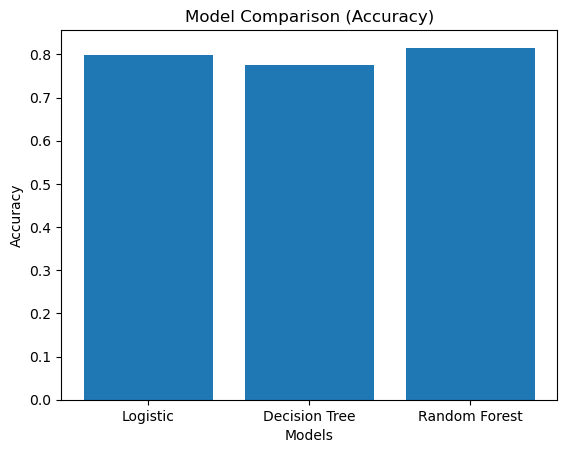

In [382]:
import matplotlib.pyplot as plt

models = ['Logistic', 'Decision Tree', 'Random Forest']
accuracy = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y1_test, y1_pred),
    accuracy_score(y2_test, y2_pred)
]

plt.bar(models, accuracy)
plt.title("Model Comparison (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [387]:
from sklearn.metrics import confusion_matrix

### Logistic Regression Heatmap

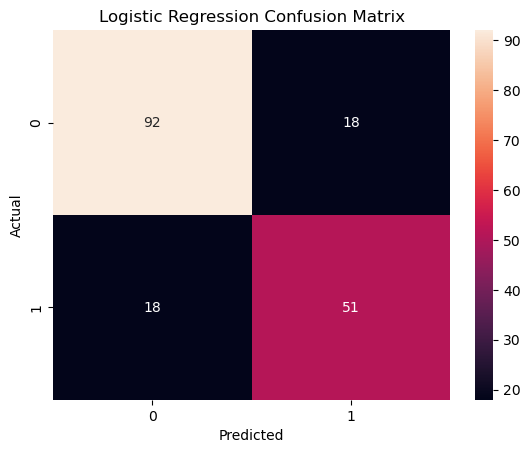

In [392]:
cm_lr = confusion_matrix(y_test, y_pred)

sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Decision Tree HeatMap

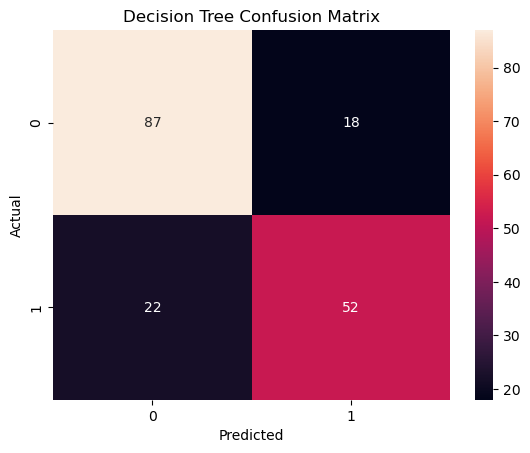

In [395]:
cm_dt = confusion_matrix(y1_test, y1_pred)

sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Random Forest Heatmap

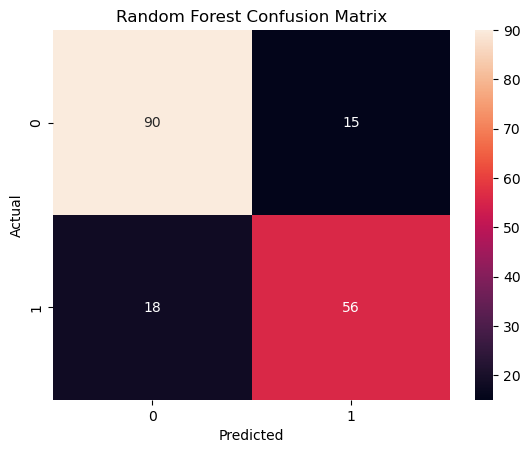

In [398]:
cm_rf = confusion_matrix(y2_test, y2_pred)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()